In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Define Path
BASE = '/content/drive/MyDrive/Text Miners/Actual Work'

# 3. Test if 'pd' works
print(f"✅ Pandas version: {pd.__version__}")

Mounted at /content/drive
✅ Pandas version: 2.2.2


In [ ]:
# Load the two final files we just created
df_nss = pd.read_csv(f'{BASE}/task3-combination/nss_output.csv')
df_sug = pd.read_csv(f'{BASE}/task3-combination/suggestions_by_aspect.csv')

# Check for listing alignment
print(f"Total Listings with Scores: {df_nss['listing_id'].nunique()}")
print(f"Total Listings with Suggestions: {df_sug['listing_id'].nunique()}")

# Ensure no critical missing values
print("\nMissing values in NSS:")
print(df_nss.isnull().sum())

Total Listings with Scores: 16527
Total Listings with Suggestions: 13371

Missing values in NSS:
listing_id    0
aspect        0
NSS_score     0
dtype: int64


In [ ]:
# 1. Load the data
df_full = pd.read_csv(f'{BASE}/task3-combination/task3_supervised_output.csv')

# 2. Re-define the signals (The notebook forgot these after the restart)
signals = ["should", "could", "wish", "needs", "missing", "would be better", "hope", "add more", "next time", "recommend"]

# 3. Filter for suggestions that are NOT positive (Neutral or Negative)
# This finds the actual 'problems' hosts need to fix
improvements = df_full[
    (df_full['comments'].str.contains('|'.join(signals), case=False, na=False)) &
    (df_full['predicted_sentiment'] != 'positive')
]

# 4. Export for Boone
improvements[['listing_id', 'predicted_aspect', 'comments']].to_csv(f'{BASE}/task3-combination/improvement_suggestions.csv', index=False)

print("✅ Improvement suggestions exported for Boone.")
print(f"Total improvements found: {len(improvements):,}")

✅ Improvement suggestions exported for Boone.
Total improvements found: 19,044


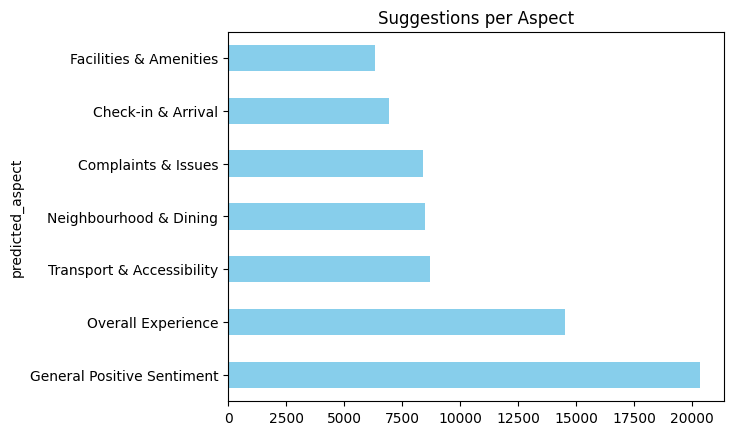

In [ ]:
import matplotlib.pyplot as plt

# See which aspects are getting the most suggestions
df_sug['predicted_aspect'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Suggestions per Aspect')
plt.show()

In [ ]:
# Check a few samples for each aspect to ensure the words match the category
for aspect in df_sug['predicted_aspect'].unique():
    print(f"=== Sample Suggestions for: {aspect} ===")
    sample = df_sug[df_sug['predicted_aspect'] == aspect]['comments'].head(2).values
    for s in sample:
        print(f" - {s[:100]}...") # Print first 100 chars
    print("\n")

=== Sample Suggestions for: Transport & Accessibility ===
 - We stayed in the apartment for a week and we enjoyed it very much. Nuttee is a very nice host, and s...
 - Nuttee was a great host! I really enjoyed her apartment and she was absolutely lovely! She even had ...


=== Sample Suggestions for: Overall Experience ===
 - My girlfriend and I recently stayed in Nuttee's condo for a month.  It is a beautiful condo, with a ...
 - Nuttee - wonderfull landlady. House very clean, with realy nice view. Usualy we stay at hotels, but ...


=== Sample Suggestions for: Neighbourhood & Dining ===
 - I stayed for one month at the condo and was realy pleased. 
<br/>The condo is at the 19th floor, qui...
 - Nuttee was a great host, she waited for us to arrive from our late afternoon flight and gave us a ru...


=== Sample Suggestions for: Complaints & Issues ===
 - Nuttee was an amazing host. She and her daughter waited for us at the lobby and gave us a quick rund...
 - Nuttee is an accommodating

In [ ]:
# Merge counts of suggestions with the NSS scores
sug_counts = df_sug.groupby('listing_id').size().reset_index(name='suggestion_count')
check_merge = pd.merge(df_nss, sug_counts, on='listing_id', how='left').fillna(0)

# Check average suggestions for low vs high scorers
low_score_avg = check_merge[check_merge['NSS_score'] < 0]['suggestion_count'].mean()
high_score_avg = check_merge[check_merge['NSS_score'] > 0.5]['suggestion_count'].mean()

print(f"Avg suggestions for unhappy listings (NSS < 0): {low_score_avg:.2f}")
print(f"Avg suggestions for happy listings (NSS > 0.5): {high_score_avg:.2f}")

Avg suggestions for unhappy listings (NSS < 0): 3.47
Avg suggestions for happy listings (NSS > 0.5): 5.90
